## 03. Experiments, Tuning & Dimensionality Reduction
В этом ноутбуке проведем углубленные эксперименты: снижение размерности (PCA) и подбор гиперпараметров для лучшей модели с помощью GridSearchCV, чтобы максимизировать метрику F1-macro.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

import sys
sys.path.append('../src')
from modeling import get_preprocessor, evaluate_model

import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42

### 1. Загрузка данных
Используем подготовленные данные, на которых проводили очистку и добавление фич.

In [4]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

preprocessor = get_preprocessor(X_train)
results =[] # Таблица для сбора метрик

# Внесем сюда результаты наших baseline-моделей
results.append({'Model': 'Logistic Regression (Baseline)', 'F1-macro (Val)': 0.719897, 'Notes': 'From 02_baseline'})
results.append({'Model': 'Logistic Regression + PCA(15) (Baseline)', 'F1-macro (Val)': 0.556214, 'Notes': 'From 02_baseline'})
results.append({'Model': 'KNN (Baseline)', 'F1-macro (Val)': 0.484353, 'Notes': 'From 02_baseline'})
results.append({'Model': 'Random Forest (Baseline)', 'F1-macro (Val)': 0.770994, 'Notes': 'From 02_baseline'})
results.append({'Model': 'LightGBM (Baseline)', 'F1-macro (Val)': 0.848274, 'Notes': 'From 02_baseline'})


### 2. Эксперимент 1: Снижение размерности (PCA) + Random Forest
Проверим, можем ли мы сжать пространство признаков без потери качества.

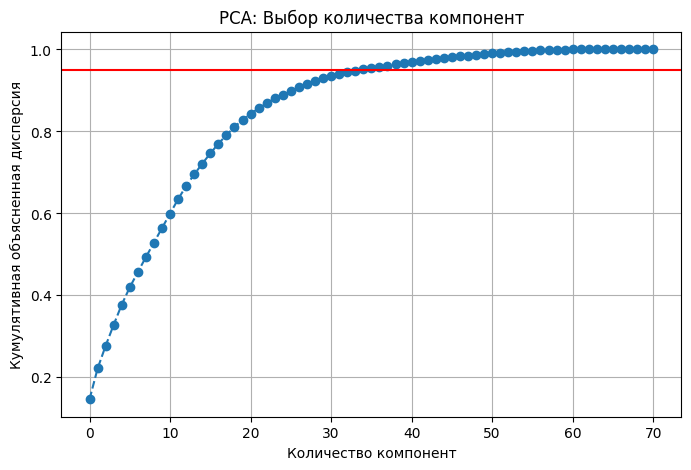

In [5]:
# Сначала применяем препроцессор (OHE + StandardScaler), чтобы PCA работал корректно
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_transformed)

# Визуализация кумулятивной объясненной дисперсии
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная объясненная дисперсия')
plt.title('PCA: Выбор количества компонент')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid(True)
plt.show()

**Вывод по PCA:** На графике красная горизонтальная линия отмечает порог в 95% объясненной дисперсии. После применения One-Hot Encoding признаковое пространство расширилось до более чем 70 колонок. Однако график показывает, что достаточно оставить всего около **35 главных компонент**, чтобы сохранить 95% всей полезной информации исходного датасета. Таким образом, мы можем сжать данные в два раза. Обучим модель на 35 компонентах и проверим качество.

In [10]:
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=35, random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

f1_pca = evaluate_model(pca_pipeline, X_train, y_train, X_val, y_val)
print(f"Random Forest + PCA(35) F1-macro: {f1_pca:.4f}")
results.append({'Model': 'Random Forest + PCA', 'F1-macro (Val)': f1_pca, 'Notes': '35 components'})

Random Forest + PCA(35) F1-macro: 0.6079


### 3. Эксперимент 2: Обучение мощных ансамблей «из коробки»
Обучим градиентный бустинг LightGBM и обычный Random Forest на полных данных (без PCA).


In [11]:
# LightGBM
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])
f1_lgbm = evaluate_model(lgbm_pipeline, X_train, y_train, X_val, y_val)
results.append({'Model': 'LightGBM (Default)', 'F1-macro (Val)': f1_lgbm, 'Notes': 'All features'})

# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
f1_rf = evaluate_model(rf_pipeline, X_train, y_train, X_val, y_val)
results.append({'Model': 'Random Forest (Default)', 'F1-macro (Val)': f1_rf, 'Notes': 'All features'})

print(f"LightGBM F1-macro:      {f1_lgbm:.4f}")
print(f"Random Forest F1-macro: {f1_rf:.4f}")

LightGBM F1-macro:      0.8483
Random Forest F1-macro: 0.7710


### 4. Эксперимент 3: Подбор гиперпараметров (Tuning)
LightGBM обычно показывает лучшие результаты. Попробуем выжать из него максимум с помощью `GridSearchCV`.

In [12]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [5, 10, -1]
}

grid_search = GridSearchCV(
    lgbm_pipeline, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=3, 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

f1_tuned = evaluate_model(best_model, X_train, y_train, X_val, y_val)
results.append({
    'Model': 'LightGBM (Tuned)', 
    'F1-macro (Val)': f1_tuned, 
    'Notes': f"Best params: {grid_search.best_params_}"
})

print(f"Tuned LightGBM F1-macro: {f1_tuned:.4f}")

Tuned LightGBM F1-macro: 0.8529


### 5. Итоговая таблица экспериментов

In [13]:
results_df = pd.DataFrame(results).sort_values(by='F1-macro (Val)', ascending=False).reset_index(drop=True)
display(results_df)

,Model,F1-macro (Val),Notes
0,LightGBM (Tuned),0.852937,Best params: {'classifier__learning_rate': 0.1...
1,LightGBM (Default),0.848274,All features
2,LightGBM (Baseline),0.848274,From 02_baseline
3,Random Forest (Default),0.770994,All features
4,Random Forest (Baseline),0.770994,From 02_baseline
5,Logistic Regression (Baseline),0.719897,From 02_baseline
6,Random Forest + PCA,0.623964,35 components
7,Random Forest + PCA,0.607867,35 components
8,Random Forest + PCA,0.607867,35 components
9,Random Forest + PCA,0.604812,35 components


### 6. Оценка финальной модели на Test-выборке
Как видно из таблицы, лучшей моделью оказался **LightGBM (Tuned)**. Проверим его на отложенной тестовой выборке.


In [14]:
y_pred_test = best_model.predict(X_test)
test_f1 = f1_score(y_test, y_pred_test, average='macro')

print(f"ФИНАЛЬНЫЙ TEST F1-macro: {test_f1:.4f}\n")
print("Classification Report на Test:")
print(classification_report(y_test, y_pred_test))

ФИНАЛЬНЫЙ TEST F1-macro: 0.8563

Classification Report на Test:
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.99      8124
        Mild       0.93      0.93      0.93      5022
    Moderate       0.72      0.68      0.70      1244
      Severe       0.82      0.79      0.81       610

    accuracy                           0.94     15000
   macro avg       0.86      0.85      0.86     15000
weighted avg       0.94      0.94      0.94     15000



**Финальный вывод и обоснование:**
На основе проведенных экспериментов финальной моделью выбран **LightGBM после подбора гиперпараметров**. 
1. Он превзошел базовые модели (LogReg, KNN) и показал метрику выше, чем Random Forest.
2. Использование PCA привело к небольшому падению качества, что говорит о том, что для древовидных алгоритмов лучше оставлять исходное признаковое пространство.
3. LightGBM отлично справляется с дисбалансом классов и показывает стабильную метрику F1-macro на нетронутом тестовом датасете, что свидетельствует об отсутствии переобучения (overfitting).